In [2]:
import os
import sys
sys.path.append(os.path.abspath(".."))


total images:  3933
total masks:  3933


<function matplotlib.pyplot.show(close=None, block=None)>

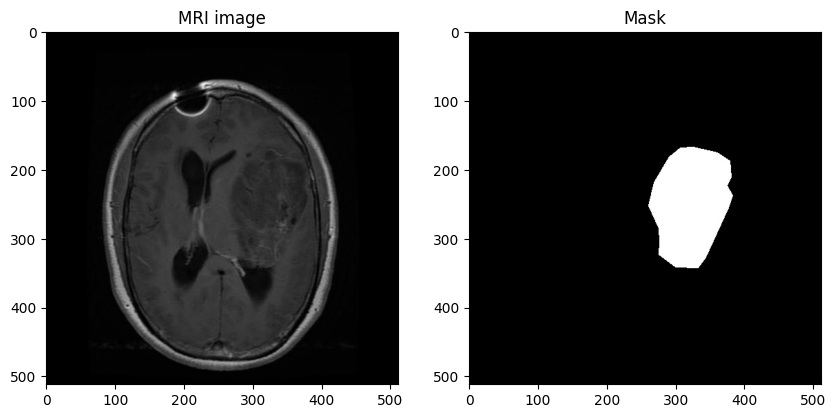

In [3]:
import os
from PIL import Image
import matplotlib.pyplot as plt

image_path=r"C:\Users\bittu bangali\OneDrive\Desktop\brain-tumor-ml\brain-tumor-mri-brisc\data\raw\brisc2025\segmentation_task\train\images"
mask_path=r"C:\Users\bittu bangali\OneDrive\Desktop\brain-tumor-ml\brain-tumor-mri-brisc\data\raw\brisc2025\segmentation_task\train\masks"


images=os.listdir(image_path)
masks=os.listdir(mask_path)

print("total images: ",len(images))
print("total masks: ",len(masks))

img=Image.open(os.path.join(image_path,images[1]))
mask=Image.open(os.path.join(mask_path,masks[1]))

plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
plt.title("MRI image")
plt.imshow(img)
plt.subplot(1,2,2)
plt.title("Mask")
plt.imshow(mask,cmap="grey")
plt.show


In [4]:
image_set = set([os.path.splitext(f)[0] for f in images])
mask_set = set([os.path.splitext(f)[0] for f in masks])
missing_image=mask_set-image_set
missing_mask=image_set-mask_set
print("missing image :",len(missing_image))
print("missing image :",len(missing_mask))

missing image : 0
missing image : 0


In [5]:
from src.dataset import BrainTumorDataset

img_dir=r"C:\Users\bittu bangali\OneDrive\Desktop\brain-tumor-ml\brain-tumor-mri-brisc\data\raw\brisc2025\segmentation_task\train\images"
mask_dir=r"C:\Users\bittu bangali\OneDrive\Desktop\brain-tumor-ml\brain-tumor-mri-brisc\data\raw\brisc2025\segmentation_task\train\masks"

from torchvision import transforms
from torchvision.transforms import InterpolationMode

image_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

mask_transform = transforms.Compose([
    transforms.Resize((256, 256), interpolation=InterpolationMode.NEAREST),
    transforms.ToTensor()
])

dataset = BrainTumorDataset(
    img_dir,
    mask_dir,
    image_transform=image_transform,
    mask_transform=mask_transform
)
# print("Total samples :",len(dataset))
# img,mask=dataset[0]
# print("Image shape :",img.shape)
# print("Mask shape: ",mask.shape)


In [6]:
from torch.utils.data import DataLoader

loader=DataLoader(dataset,batch_size=16,shuffle=True)

for imgs,masks in loader:
    print(imgs.shape)
    print(masks.shape)
    break


torch.Size([16, 3, 256, 256])
torch.Size([16, 1, 256, 256])


In [7]:
import torch
class Encodere(torch.nn.Module):
    def __init__(self,INPUT_C,OUTPUT_C,K_SIZE=3):
        super().__init__()
        self.Conv1=torch.nn.Conv2d(in_channels=INPUT_C,out_channels=OUTPUT_C,kernel_size=K_SIZE,padding='same')
        self.Active1=torch.nn.ReLU()
        self.Conv2=torch.nn.Conv2d(in_channels=OUTPUT_C,out_channels=OUTPUT_C,kernel_size=K_SIZE,padding='same')
        self.Active2=torch.nn.ReLU()
        self.Pool=torch.nn.MaxPool2d(kernel_size=2)
    def forward(self, input):
        Output=self.Conv1(input)
        Output=self.Active1(Output)
        Output=self.Conv2(Output)
        Output=self.Active2(Output)
        #Output=self.Pool(Output)
        return self.Pool(Output),Output

In [8]:
class Decodere(torch.nn.Module):
    def __init__(self,INPUT_C,OUTPUT_C,K_SIZE=3):
        super().__init__()
        self.Upscale= torch.nn.ConvTranspose2d(in_channels=INPUT_C,out_channels=OUTPUT_C,kernel_size=2,stride=2)
        self.Conv1=torch.nn.Conv2d(in_channels=2*OUTPUT_C,out_channels=OUTPUT_C,kernel_size=K_SIZE,padding='same')
        self.Active1=torch.nn.ReLU()
        self.Conv2=torch.nn.Conv2d(in_channels=OUTPUT_C,out_channels=OUTPUT_C,kernel_size=K_SIZE,padding='same')
        self.Active2=torch.nn.ReLU()
    def forward(self, input,skip):
        Output=self.Upscale(input)
        Output=torch.concat([Output,skip],dim=1)
        Output=self.Conv1(Output)
        Output=self.Active1(Output)
        Output=self.Conv2(Output)
        Output=self.Active2(Output)
        #Output=self.Pool(Output)
        return Output

In [ ]:
class Unet(torch.nn.Module):
    def __init__(self,):
        super().__init__()
        self.downsample1=Encodere(3,64)
        self.downsample2=Encodere(64,128)
        self.downsample3=Encodere(128,256)
        self.downsample4=Encodere(256,512)
        self.bottle_neck1=torch.nn.Conv2d(in_channels=512,out_channels=1024,kernel_size=3,padding='same')
        self.activation1=torch.nn.ReLU()
        self.bottle_neck2=torch.nn.Conv2d(in_channels=1024,out_channels=1024,kernel_size=3,padding='same')
        self.activation2=torch.nn.ReLU()
        self.upsample1=Decodere(1024,512)
        self.upsample2=Decodere(512,256)
        self.upsample3=Decodere(256,128)
        self.upsample4=Decodere(128,64)
        self.Output=torch.nn.Conv2d(in_channels=64,out_channels=1,kernel_size=1,padding=1)
    def forward(self,input):
        x,skip1=self.downsample1(input)
        x,skip2=self.downsample2(x)
        x,skip3=self.downsample3(x)
        x,skip4=self.downsample4(x)
        x=self.bottle_neck1(x)
        x=self.activation1(x)
        x=self.bottle_neck2(x)
        x=self.activation2(x)
        x=self.upsample1(x,skip4)
        x=self.upsample2(x,skip3)
        x=self.upsample3(x,skip2)
        x=self.upsample4(x,skip1)
        x=self.Output(x)
        return x

In [10]:
unt = Unet()
print(unt)

Unet(
  (downsample1): Encodere(
    (Conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (Active1): ReLU()
    (Conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (Active2): ReLU()
    (Pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (downsample2): Encodere(
    (Conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (Active1): ReLU()
    (Conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (Active2): ReLU()
    (Pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (downsample3): Encodere(
    (Conv1): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (Active1): ReLU()
    (Conv2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (Active2): ReLU()
    (Pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (downsample4): Encodere(
    (Conv1): 

In [1]:
device="cuda" if torch.cuda.is_available() else "cpu"
model=Unet().to(device)

NameError: name 'torch' is not defined

In [ ]:
import torch
import torch.nn as nn

class Dice(nn.Module):
    def __init__(self,smooth=1e-6):
        super().__init__()
        self.smooth=smooth
    def forward(self,preds,targets):
        preds=torch.sigmoid(preds)
        preds=preds.view(-1)
        targets=targets.view(-1)
        intersect=(preds*targets).sum()
        dice=(2*intersect+self.smooth)/(preds.sum()+targets.sum()+self.smooth)
        return 1-dice

BCE=nn.BCEWithLogitsLoss()
dice=Dice()

def Loss(preds,targets):
    return 0.3*BCE(preds,targets)+0.7*dice(preds,targets)



In [13]:
# !pip install tqdm
import tqdm
optimizer=torch.optim.Adam(model.parameters(),lr=1e-4)

TRAIN = False
if TRAIN:
    total_epochs=10
    total_batch = total_epochs*len(loader)
    with tqdm.tqdm(total=total_batch) as b:
        for epchos in range(total_epochs):
            model.train()
            total_loss=0
            for img,mask in loader:
                img=img.to(device)
                mask=mask.to(device)
                #forward
                pred=model(img)
                loss=Loss(pred,mask)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                total_loss+=loss.item()
                b.update(1)

            print(f"Total epochs :{epchos+1} Loss :{total_loss/len(loader):.4f}") 

In [14]:
model = Unet()
model.load_state_dict(torch.load(r"C:\Users\bittu bangali\OneDrive\Desktop\sem6_midterm\model.pth", weights_only=True))
model.eval()

Unet(
  (downsample1): Encodere(
    (Conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (Active1): ReLU()
    (Conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (Active2): ReLU()
    (Pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (downsample2): Encodere(
    (Conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (Active1): ReLU()
    (Conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (Active2): ReLU()
    (Pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (downsample3): Encodere(
    (Conv1): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (Active1): ReLU()
    (Conv2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (Active2): ReLU()
    (Pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (downsample4): Encodere(
    (Conv1): 

In [18]:
image, mask = dataset[77]

<Figure size 1200x600 with 0 Axes>

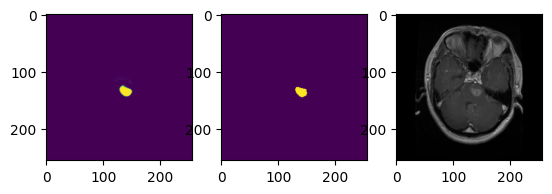

In [20]:
prediction = model(image[None, :, :, :])

plt.figure(figsize=(12,6))
fig, axes = plt.subplots(1, 3)
axes[0].imshow(torch.sigmoid(prediction).squeeze().detach().numpy())
axes[1].imshow(mask.squeeze().detach().numpy())
axes[2].imshow(image.squeeze().detach().numpy().transpose(1, 2, 0))
